In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
from torch.utils.data import Subset
import torch.optim as optim
import torch.nn as nn

import torchvision
from torchvision import transforms
from PIL import Image
import timm

from transformers import DistilBertTokenizer, DistilBertModel

from sklearn.model_selection import train_test_split
import torch.optim as optim

In [2]:
batch_size = 16

## Loading Dataset

In [3]:
path = "cleaned_sample_train"
img_path = "images"

In [4]:
df = pd.read_csv(path, sep = "\t")
max_words = max([len(str(x).split()) for x in df['title']])
print(max_words)

54


In [5]:
class FakedditDatasetOptimized(Dataset):
    def __init__(self, path, img_path, transform = None):
        self.transform = transform
        self.path = path
        self.img_path = img_path

        self.data = pd.read_csv(path, sep = "\t")
        self.tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-cased')   # capitalization on words matter except for start word


    def __len__(self):
        return len(self.data)

    def get_img_path(self,img_id):
        return f"{self.img_path}/{img_id}.jpg"

    def __getitem__(self,index):
        row = self.data.iloc[index]
        text = str(row['title'])  # str ensures that even if title empty it returns empty string not NaN
        text_tokenized = self.tokenizer(text,
                                        padding = 'max_length',  # setting padding as 'max_length' tells tokenizer to use max_length value and add padding as needed
                                        truncation = True,
                                        max_length = 64,
                                        return_tensors = 'pt')
        input_ids = text_tokenized['input_ids'].flatten()    # tokenizer returns dictionary of input_ids and attention_mask
        attention_mask = text_tokenized['attention_mask'].flatten()
        label = row['2_way_label']
        label = torch.tensor(label, dtype = torch.long)

        image = Image.open(self.get_img_path(row['id'])).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return {
            'tokens': input_ids,
            'mask': attention_mask,
            'img': image,
            'label': label
        }

If a word is tokenized with word having only 10 words the rest of the rest 54 words would be tokenized as just 0 i.e padding and if the transformer pays attention to them then it would be a waste and would have our madel deviate hence we need to use Attnetion Mask

input_ids are the words where words are present and are later converted into tokens eg hello world = [7689,1239, 0, 0, ... till the max_length] where as attention mask tells where the model needs to pay attention by marking those indices as 1 and the other as 0 so for above example it will be [1, 1, 0, 0, 0, ...] 

In a Cross-Modal Inconsistency project, if the text says "Look at this tall building" but the model sees a "squashed, wide building" because of bad resizing the model might not be able to detect inconsistency properly to solve that we will be using this two-step approach:
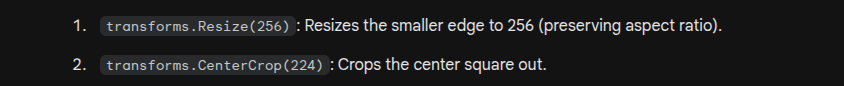

In [6]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# splitting the dataset
df = df.drop(columns = ['created_utc', 'hasImage', 'image_url', 'linked_submission_id', '3_way_label', '6_way_label', 'author' ])
indices = list(range(len(df)))
train_indices, val_indices = train_test_split(
    indices,
    test_size = 0.1,
    stratify = df['2_way_label'],
    random_state = 42,
    shuffle = True
)

train_data = FakedditDatasetOptimized(
    path = path,
    img_path = img_path,
    transform = train_transform
)

val_data = FakedditDatasetOptimized(
    path = path,
    img_path = img_path,
    transform = val_transform
)

train_dataset = Subset(train_data, train_indices)
val_dataset = Subset(train_data, val_indices)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [7]:
# Pulling a single batch from your train_loader
batch = next(iter(train_loader))

print(f"Tokens shape: {batch['tokens'].shape}")   
print(f"Mask shape:   {batch['mask'].shape}")     
print(f"Image shape:  {batch['img'].shape}")      
print(f"Label shape:  {batch['label'].shape}")    

Tokens shape: torch.Size([16, 64])
Mask shape:   torch.Size([16, 64])
Image shape:  torch.Size([16, 3, 224, 224])
Label shape:  torch.Size([16])


## Fusion Model

In [8]:
class FusionModel(nn.Module):
    def __init__(self, num_classes=2):
        super(FusionModel, self).__init__()
        
        # Text Branch: DistilBERT
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-cased')
        
        # Vision Branch: MobileViT
        # num_classes=0 strips the final layer and returns the pooled features
        self.mobilevit = timm.create_model('mobilevit_s', pretrained=True, num_classes=0)
        
        # Fusion Classifier
        # Input size = 768 (BERT) + 640 (MobileViT) = 1408
        self.classifier = nn.Sequential(
            nn.Linear(768 + 640, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, input_ids, attention_mask, pixel_values):
        # Text Forward Pass
        text_outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        # Slicing the [CLS] token: [batch_size, 768]
        text_features = text_outputs.last_hidden_state[:, 0, :]
        
        # Vision Forward Pass: [batch_size, 640]
        vision_features = self.mobilevit(pixel_values)
        
        # Multimodal Fusion (Concatenation)
        fused_features = torch.cat((text_features, vision_features), dim=1)
        
        # Final Prediction
        logits = self.classifier(fused_features)
        return logits

# Initialize the model
model = FusionModel(num_classes=2)

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

the last_hidden_state returns a tensor<br>
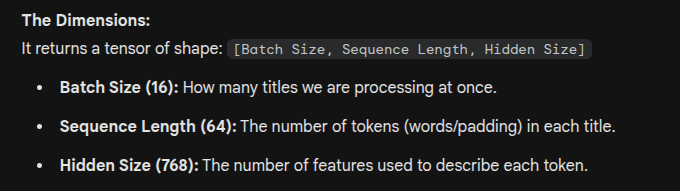
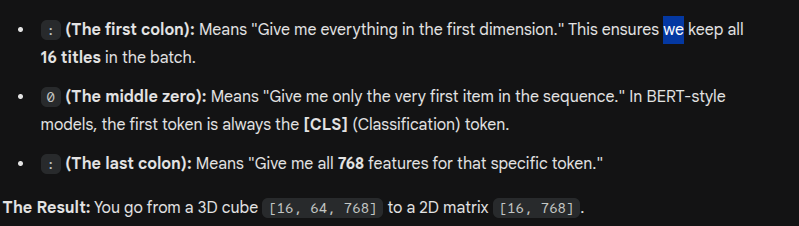

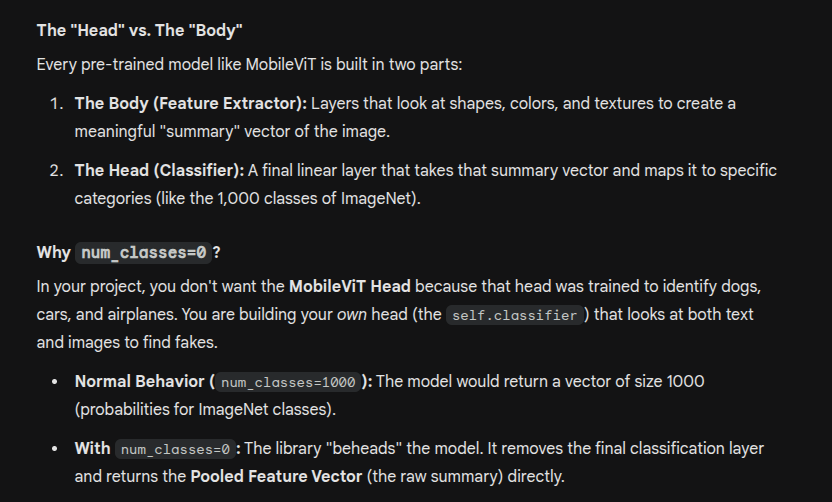

## Training 

In [12]:
# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
# We start with a small learning rate to avoid destroying pre-trained weights
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

num_epoch = 10

In [13]:
def train_and_validate(model, train_loader, val_loader, criterion, optimizer, device, num_epochs):
    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for batch in train_loader:
            input_ids = batch['tokens'].to(device)
            attention_mask = batch['mask'].to(device)
            pixel_values = batch['img'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask, pixel_values)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                v_input_ids = batch['tokens'].to(device)
                v_mask = batch['mask'].to(device)
                v_img = batch['img'].to(device)
                v_labels = batch['label'].to(device)

                v_logits = model(v_input_ids, v_mask, v_img)
                v_loss = criterion(v_logits, v_labels)

                val_loss += v_loss.item()
                _, v_predicted = torch.max(v_logits, 1)
                val_total += v_labels.size(0)
                val_correct += (v_predicted == v_labels).sum().item()

        # Stats
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_loss/len(train_loader):.4f} | Acc: {100*train_correct/train_total:.2f}%")
        print(f"Val Loss: {val_loss/len(val_loader):.4f} | Acc: {100*val_correct/val_total:.2f}%")
        print("-" * 30)

# Execute the training
train_and_validate(model, train_loader, val_loader, criterion, optimizer, device, num_epoch)

Epoch 1/10
Train Loss: 0.4780 | Acc: 75.59%
Val Loss: 0.3791 | Acc: 85.43%
------------------------------
Epoch 2/10
Train Loss: 0.2516 | Acc: 90.22%
Val Loss: 0.3394 | Acc: 90.45%
------------------------------
Epoch 3/10
Train Loss: 0.0976 | Acc: 96.31%
Val Loss: 0.4328 | Acc: 86.43%
------------------------------
Epoch 4/10
Train Loss: 0.0299 | Acc: 98.99%
Val Loss: 0.6475 | Acc: 83.42%
------------------------------
Epoch 5/10
Train Loss: 0.0322 | Acc: 99.11%
Val Loss: 0.5391 | Acc: 88.94%
------------------------------
Epoch 6/10
Train Loss: 0.0399 | Acc: 98.83%
Val Loss: 0.5443 | Acc: 86.43%
------------------------------
Epoch 7/10
Train Loss: 0.0190 | Acc: 99.61%
Val Loss: 0.4926 | Acc: 87.44%
------------------------------
Epoch 8/10
Train Loss: 0.0100 | Acc: 99.72%
Val Loss: 0.5576 | Acc: 88.44%
------------------------------
Epoch 9/10
Train Loss: 0.0011 | Acc: 100.00%
Val Loss: 0.6427 | Acc: 89.45%
------------------------------
Epoch 10/10
Train Loss: 0.0004 | Acc: 100.00%